## Reduced Feature Analysis 
In this notebook, we analyse the difference in performance of the balanced Random Forest Classifier model on all 3 datasets for different variations of features.

In [ ]:
#Installing all require libraries
%pip install pandas
%pip install seaborn
%pip install matplotlib
%pip install ipython
%pip install scikit-learn
%pip install imbalanced-learn

In [2]:
# All imports needed for this experiment

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import  StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import  accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [3]:
# Load the aligned datasets
df1 = pd.read_csv("../data/aligned/dataset_1_aligned.csv")
df2 = pd.read_csv("../data/aligned/dataset_2_aligned.csv")
df3 = pd.read_csv("../data/aligned/dataset_3_aligned.csv")


In [4]:
# Rename the target column to 'target' for consistency
df1 = df1.rename(columns={'Class':'target'})
df1.head(5)

,Unnamed: 0,bp,sg,al,su,rbc,bu,sc,sod,pot,hemo,wc,rc,htn,target
0,0,80.0,1.020,1.0,0.0,NaN,36.0,1.2,NaN,NaN,15.4,7800,5.2,yes,1
1,1,50.0,1.020,4.0,0.0,NaN,18.0,0.8,NaN,NaN,11.3,6000,NaN,no,1
2,2,80.0,1.010,2.0,3.0,normal,53.0,1.8,NaN,NaN,9.6,7500,NaN,no,1
3,3,70.0,1.005,4.0,0.0,normal,56.0,3.8,111.0,2.5,11.2,6700,3.9,yes,1
4,4,80.0,1.010,2.0,0.0,normal,26.0,1.4,NaN,NaN,11.6,7300,4.6,no,1


In [5]:
# Rename the target column to 'target' for consistency
df2 = df2.rename(columns={'Class':'target'})
df2.head(5)

,Unnamed: 0,bp,sg,al,su,rbc,bu,sc,sod,pot,hemo,wc,rc,htn,target
0,0,80.0,1.020,1.0,0.0,1.0,36.0,1.2,137.53,4.63,15.4,7800.0,5.20,1.0,1
1,1,50.0,1.020,4.0,0.0,1.0,18.0,0.8,137.53,4.63,11.3,6000.0,4.71,0.0,1
2,2,80.0,1.010,2.0,3.0,1.0,53.0,1.8,137.53,4.63,9.6,7500.0,4.71,0.0,1
3,3,70.0,1.005,4.0,0.0,1.0,56.0,3.8,111.00,2.50,11.2,6700.0,3.90,1.0,1
4,4,80.0,1.010,2.0,0.0,1.0,26.0,1.4,137.53,4.63,11.6,7300.0,4.60,0.0,1


In [6]:
# Rename the target column to 'target' for consistency
df3 = df3.rename(columns={'Class':'target'})
df3.head(5)

,Unnamed: 0,bp,sg,al,su,rbc,bu,sc,sod,pot,hemo,wc,rc,htn,target
0,0,167,1.023,1,4,normal,169.101369,7.55,146.068410,6.272576,11.8,5791,5.6,yes,0
1,1,127,1.023,3,2,normal,183.223479,13.37,123.501427,5.611303,8.2,5390,4.6,no,1
2,2,148,1.016,0,0,abnormal,193.141665,9.49,149.456527,3.965957,10.1,12098,4.7,no,0
3,3,98,1.017,4,0,abnormal,125.939396,10.98,131.758843,4.980997,14.0,6747,4.8,no,0
4,4,174,1.015,1,1,normal,197.188600,3.01,120.912465,4.097602,16.1,5759,5.7,no,0


In [7]:
# Function to train and evaluate a model on a given subset of features
def evaluate_feature_subset_balanced(df, selected_features, random_state=42):

    X = df[selected_features]
    y = df["target"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

    numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ])

    X_train_t = preprocessor.fit_transform(X_train)
    X_test_t = preprocessor.transform(X_test)

    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_t, y_train)

    model = RandomForestClassifier(class_weight="balanced",
        random_state=random_state)
    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test_t)
    y_prob = model.predict_proba(X_test_t)[:, 1]

    return {
        "n_features": len(selected_features),
        "features": selected_features,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob)
    }


In [8]:
# Function to train and evaluate a model on a given subset of features
def evaluate_feature_subset_unbalanced(df, selected_features, random_state=42):

    X = df[selected_features]
    y = df["target"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

    numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ])

    X_train_t = preprocessor.fit_transform(X_train)
    X_test_t = preprocessor.transform(X_test)

    # smote = SMOTE(random_state=42)
    # X_train_smote, y_train_smote = smote.fit_resample(X_train_t, y_train)

    model = RandomForestClassifier(random_state=random_state)
    model.fit(X_train_t, y_train)

    y_pred = model.predict(X_test_t)
    y_prob = model.predict_proba(X_test_t)[:, 1]

    return {
        "n_features": len(selected_features),
        "features": selected_features,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob)
    }


In [9]:
def build_feature_progression_tables(df, feature_sets):
    unbalanced_results = [
        evaluate_feature_subset_unbalanced(df, selected_features, random_state=42)
        for selected_features in feature_sets
    ]
    balanced_results = [
        evaluate_feature_subset_balanced(df, selected_features, random_state=42)
        for selected_features in feature_sets
    ]

    return pd.DataFrame(unbalanced_results), pd.DataFrame(balanced_results)


In [10]:
# Dataset 1 reduced feature analysis

# Add one feature at a time based on importance
f1 = ['hemo']
f2 = ['hemo', 'sc']
f3 = ['hemo', 'sc', 'sg']
f4 = ['hemo', 'sc', 'sg', 'rc']
f5 = ['hemo', 'sc', 'sg', 'rc', 'al']
f6 = ['hemo', 'sc', 'sg', 'rc', 'al', 'htn']
f7 = ['hemo', 'sc', 'sg', 'rc', 'al', 'htn', 'bu']
f8 = ['hemo', 'sc', 'sg', 'rc', 'al', 'htn', 'bu', 'sod']
f9 = ['hemo', 'sc', 'sg', 'rc', 'al', 'htn', 'bu', 'sod', 'bp']
f10 = ['hemo', 'sc', 'sg', 'rc', 'al', 'htn', 'bu', 'sod', 'bp', 'su']
f11 = ['hemo', 'sc', 'sg', 'rc', 'al', 'htn', 'bu', 'sod', 'bp', 'su', 'pot']
f12 = ['hemo', 'sc', 'sg', 'rc', 'al', 'htn', 'bu', 'sod', 'bp', 'su', 'pot', 'wc']
f13 = ['hemo', 'sc', 'sg', 'rc', 'al', 'htn', 'bu', 'sod', 'bp','su', 'pot', 'wc', 'rbc']

In [11]:
# Dataset 1 - Compare unbalanced and balanced models across gradually increasing feature sets

dataset1_feature_sets = [f1, f2, f3, f4, f5, f6, f7, f8, f9, f10, f11, f12, f13]

results_df_unbalanced, results_df = build_feature_progression_tables(df1, dataset1_feature_sets)

display(results_df_unbalanced)
display(results_df)


,n_features,features,accuracy,precision,recall,f1,roc_auc
0,1,[hemo],0.9375,0.941176,0.96,0.950495,0.987333
1,2,"[hemo, sc]",0.9500,0.942308,0.98,0.960784,0.993333
2,3,"[hemo, sc, sg]",0.9875,1.000000,0.98,0.989899,0.999333
3,4,"[hemo, sc, sg, rc]",0.9875,0.980392,1.00,0.990099,1.000000
4,5,"[hemo, sc, sg, rc, al]",1.0000,1.000000,1.00,1.000000,1.000000
5,6,"[hemo, sc, sg, rc, al, htn]",1.0000,1.000000,1.00,1.000000,1.000000
6,7,"[hemo, sc, sg, rc, al, htn, bu]",1.0000,1.000000,1.00,1.000000,1.000000
7,8,"[hemo, sc, sg, rc, al, htn, bu, sod]",1.0000,1.000000,1.00,1.000000,1.000000
8,9,"[hemo, sc, sg, rc, al, htn, bu, sod, bp]",1.0000,1.000000,1.00,1.000000,1.000000
9,10,"[hemo, sc, sg, rc, al, htn, bu, sod, bp, su]",1.0000,1.000000,1.00,1.000000,1.000000


,n_features,features,accuracy,precision,recall,f1,roc_auc
0,1,[hemo],0.9250,0.940000,0.94,0.940000,0.983667
1,2,"[hemo, sc]",0.9750,0.980000,0.98,0.980000,0.993333
2,3,"[hemo, sc, sg]",0.9875,1.000000,0.98,0.989899,1.000000
3,4,"[hemo, sc, sg, rc]",0.9875,0.980392,1.00,0.990099,1.000000
4,5,"[hemo, sc, sg, rc, al]",1.0000,1.000000,1.00,1.000000,1.000000
5,6,"[hemo, sc, sg, rc, al, htn]",1.0000,1.000000,1.00,1.000000,1.000000
6,7,"[hemo, sc, sg, rc, al, htn, bu]",1.0000,1.000000,1.00,1.000000,1.000000
7,8,"[hemo, sc, sg, rc, al, htn, bu, sod]",1.0000,1.000000,1.00,1.000000,1.000000
8,9,"[hemo, sc, sg, rc, al, htn, bu, sod, bp]",1.0000,1.000000,1.00,1.000000,1.000000
9,10,"[hemo, sc, sg, rc, al, htn, bu, sod, bp, su]",1.0000,1.000000,1.00,1.000000,1.000000


*Insights*

For Dataset 1, performance rises quickly with the first few features and then plateaus by around five features. Hemoglobin remains the strongest single feature, but the jump from the top 1-2 features to the full top-5 set is what closes the gap to near-perfect performance. After that point, adding more features does not materially improve F1 or ROC-AUC, so the elbow is effectively around five features for both the balanced and unbalanced models.

In [12]:
# Dataset 2 reduced feature analysis

# Add one feature at a time based on importance
f1 = ['hemo']
f2 = ['hemo', 'sc']
f3 = ['hemo', 'sc', 'sg']
f4 = ['hemo', 'sc', 'sg', 'rc']
f5 = ['hemo', 'sc', 'sg', 'al', 'rc']
f6 = ['hemo', 'sc', 'sg', 'al', 'rc', 'htn']
f7 = ['hemo', 'sc', 'sg', 'al', 'rc', 'htn', 'bu']
f8 = ['hemo', 'sc', 'sg', 'al', 'rc', 'htn', 'bu', 'sod']
f9 = ['hemo', 'sc', 'sg', 'al', 'rc', 'htn', 'bu', 'sod', 'bp']
f10 = ['hemo', 'sc', 'sg', 'al', 'rc', 'htn', 'bu', 'sod', 'bp', 'su']
f11 = ['hemo', 'sc', 'sg', 'al', 'rc', 'htn', 'bu', 'sod', 'bp', 'su', 'wc']
f12 = ['hemo', 'sc', 'sg', 'al', 'rc', 'htn', 'bu', 'sod', 'bp', 'su', 'wc', 'pot']
f13 = ['hemo', 'sc', 'sg', 'al', 'rc', 'htn', 'bu', 'sod', 'bp', 'su', 'wc', 'pot', 'rbc']

In [13]:
# Dataset 2 - Compare unbalanced and balanced models across gradually increasing feature sets

dataset2_feature_sets = [f1, f2, f3, f4, f5, f6, f7, f8, f9, f10, f11, f12, f13]

results_df2_unbalanced, results_df2 = build_feature_progression_tables(df2, dataset2_feature_sets)

display(results_df2_unbalanced)
display(results_df2)


,n_features,features,accuracy,precision,recall,f1,roc_auc
0,1,[hemo],0.9250,0.978261,0.90,0.937500,0.940667
1,2,"[hemo, sc]",0.9500,0.979167,0.94,0.959184,0.969667
2,3,"[hemo, sc, sg]",0.9875,1.000000,0.98,0.989899,0.999333
3,4,"[hemo, sc, sg, rc]",0.9875,1.000000,0.98,0.989899,0.999333
4,5,"[hemo, sc, sg, al, rc]",1.0000,1.000000,1.00,1.000000,1.000000
5,6,"[hemo, sc, sg, al, rc, htn]",1.0000,1.000000,1.00,1.000000,1.000000
6,7,"[hemo, sc, sg, al, rc, htn, bu]",1.0000,1.000000,1.00,1.000000,1.000000
7,8,"[hemo, sc, sg, al, rc, htn, bu, sod]",1.0000,1.000000,1.00,1.000000,1.000000
8,9,"[hemo, sc, sg, al, rc, htn, bu, sod, bp]",1.0000,1.000000,1.00,1.000000,1.000000
9,10,"[hemo, sc, sg, al, rc, htn, bu, sod, bp, su]",1.0000,1.000000,1.00,1.000000,1.000000


,n_features,features,accuracy,precision,recall,f1,roc_auc
0,1,[hemo],0.9000,0.977273,0.86,0.914894,0.933667
1,2,"[hemo, sc]",0.9250,0.978261,0.90,0.937500,0.954000
2,3,"[hemo, sc, sg]",0.9875,1.000000,0.98,0.989899,0.999333
3,4,"[hemo, sc, sg, rc]",0.9875,1.000000,0.98,0.989899,0.999000
4,5,"[hemo, sc, sg, al, rc]",1.0000,1.000000,1.00,1.000000,1.000000
5,6,"[hemo, sc, sg, al, rc, htn]",1.0000,1.000000,1.00,1.000000,1.000000
6,7,"[hemo, sc, sg, al, rc, htn, bu]",1.0000,1.000000,1.00,1.000000,1.000000
7,8,"[hemo, sc, sg, al, rc, htn, bu, sod]",1.0000,1.000000,1.00,1.000000,1.000000
8,9,"[hemo, sc, sg, al, rc, htn, bu, sod, bp]",1.0000,1.000000,1.00,1.000000,1.000000
9,10,"[hemo, sc, sg, al, rc, htn, bu, sod, bp, su]",1.0000,1.000000,1.00,1.000000,1.000000


*Insights*

Dataset 2 follows the same overall pattern as Dataset 1: the earliest features carry most of the predictive signal, and performance becomes essentially saturated once the top five features are included. The unbalanced model is slightly stronger at the smallest feature counts, but the balanced model catches up as more informative features are added. The elbow again appears around five features, where both F1 and ROC-AUC reach their best or near-best values and further feature additions provide little extra value.

In [14]:
# Dataset 3 reduced feature analysis

# Add one feature at a time based on importance
f1 = ['al']
f2 = ['al', 'su']
f3 = ['al', 'su', 'sg']
f4 = ['al', 'su', 'sg', 'rc']
f5 = ['al', 'su', 'sg', 'rc', 'sod']
f6 = ['al', 'su', 'sg', 'rc', 'sod', 'wc']
f7 = ['al', 'su', 'sg', 'rc', 'sod', 'wc', 'pot']
f8 = ['al', 'su', 'sg', 'rc', 'sod', 'wc', 'pot', 'hemo']
f9 = ['al', 'su', 'sg', 'rc', 'sod', 'wc', 'pot', 'hemo', 'sc']
f10 = ['al', 'su', 'sg', 'rc', 'sod', 'wc', 'pot', 'hemo', 'sc', 'bu']
f11 = ['al', 'su', 'sg', 'rc', 'sod', 'wc', 'pot', 'hemo', 'sc', 'bu', 'bp']
f12 = ['al', 'su', 'sg', 'rc', 'sod', 'wc', 'pot', 'hemo', 'sc', 'bu', 'bp', 'rbc']
f13 = ['al', 'su', 'sg', 'rc', 'sod', 'wc', 'pot', 'hemo', 'sc', 'bu', 'bp', 'rbc', 'htn']

In [15]:
# Dataset 3 - Compare unbalanced and balanced models across gradually increasing feature sets

dataset3_feature_sets = [f1, f2, f3, f4, f5, f6, f7, f8, f9, f10, f11, f12, f13]

results_df3_unbalanced, results_df3 = build_feature_progression_tables(df3, dataset3_feature_sets)

display(results_df3_unbalanced)
display(results_df3)


,n_features,features,accuracy,precision,recall,f1,roc_auc
0,1,[al],0.800146,0.000000,0.000000,0.000000,0.505912
1,2,"[al, su]",0.800146,0.000000,0.000000,0.000000,0.503802
2,3,"[al, su, sg]",0.794547,0.074074,0.002436,0.004717,0.487649
3,4,"[al, su, sg, rc]",0.731500,0.172093,0.090134,0.118305,0.489920
4,5,"[al, su, sg, rc, sod]",0.787731,0.140845,0.012180,0.022422,0.505884
5,6,"[al, su, sg, rc, sod, wc]",0.797955,0.090909,0.001218,0.002404,0.486085
6,7,"[al, su, sg, rc, sod, wc, pot]",0.799416,0.200000,0.001218,0.002421,0.482630
7,8,"[al, su, sg, rc, sod, wc, pot, hemo]",0.799903,0.000000,0.000000,0.000000,0.491850
8,9,"[al, su, sg, rc, sod, wc, pot, hemo, sc]",0.800146,0.500000,0.001218,0.002430,0.496383
9,10,"[al, su, sg, rc, sod, wc, pot, hemo, sc, bu]",0.800146,0.000000,0.000000,0.000000,0.488147


,n_features,features,accuracy,precision,recall,f1,roc_auc
0,1,[al],0.599562,0.206553,0.353228,0.260674,0.506126
1,2,"[al, su]",0.491723,0.207120,0.545676,0.300268,0.505327
2,3,"[al, su, sg]",0.557205,0.190447,0.373934,0.252363,0.488539
3,4,"[al, su, sg, rc]",0.704236,0.180195,0.135201,0.154489,0.485024
4,5,"[al, su, sg, rc, sod]",0.750730,0.214085,0.092570,0.129252,0.491369
5,6,"[al, su, sg, rc, sod, wc]",0.765579,0.199153,0.057247,0.088931,0.488132
6,7,"[al, su, sg, rc, sod, wc, pot]",0.774830,0.170886,0.032887,0.055158,0.486995
7,8,"[al, su, sg, rc, sod, wc, pot, hemo]",0.785297,0.214953,0.028015,0.049569,0.490792
8,9,"[al, su, sg, rc, sod, wc, pot, hemo, sc]",0.785540,0.134146,0.013398,0.024363,0.496994
9,10,"[al, su, sg, rc, sod, wc, pot, hemo, sc, bu]",0.788705,0.149254,0.012180,0.022523,0.486901


*Insights*

Dataset 3 behaves very differently. The unbalanced model reaches high accuracy early on, but its F1 score stays close to zero for most feature counts, which shows that accuracy is hiding poor minority-class detection. The balanced model gives a more honest picture, it improves F1 noticeably with the first few features, peaking very early (around 2 features), after which performance gradually declines. However, ROC-AUC remains near 0.5 across all feature counts indicating that the model is unable to effectively distinguish between classes, suggesting a weak or noisy signal in the dataset. There is no strong elbow here in the same sense as Datasets 1 and 2, and since performance does not improve with additional features, the smallest feature set that gives the highest balanced F1 represents the most effective configuration, although overall performance remains limited.

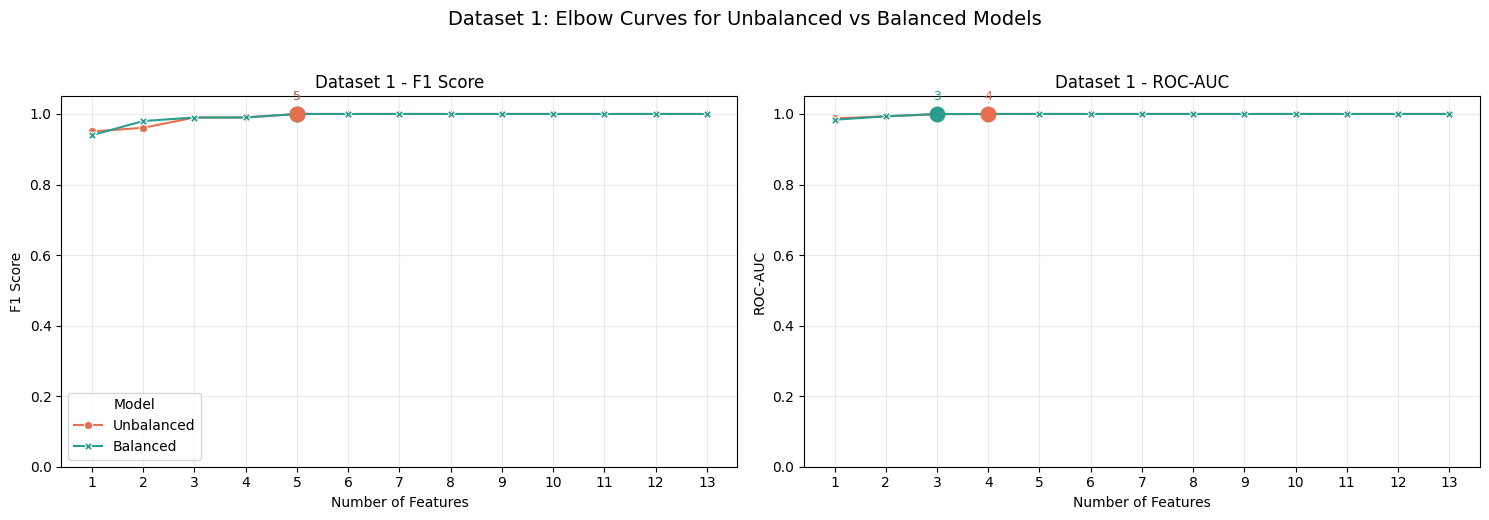

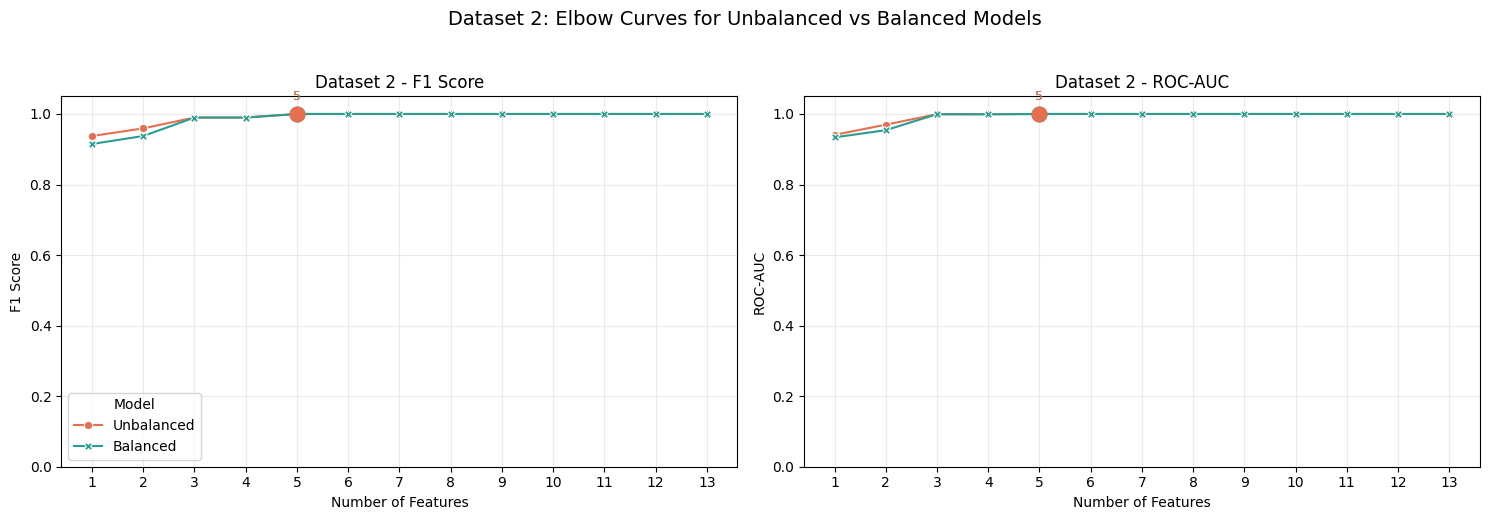

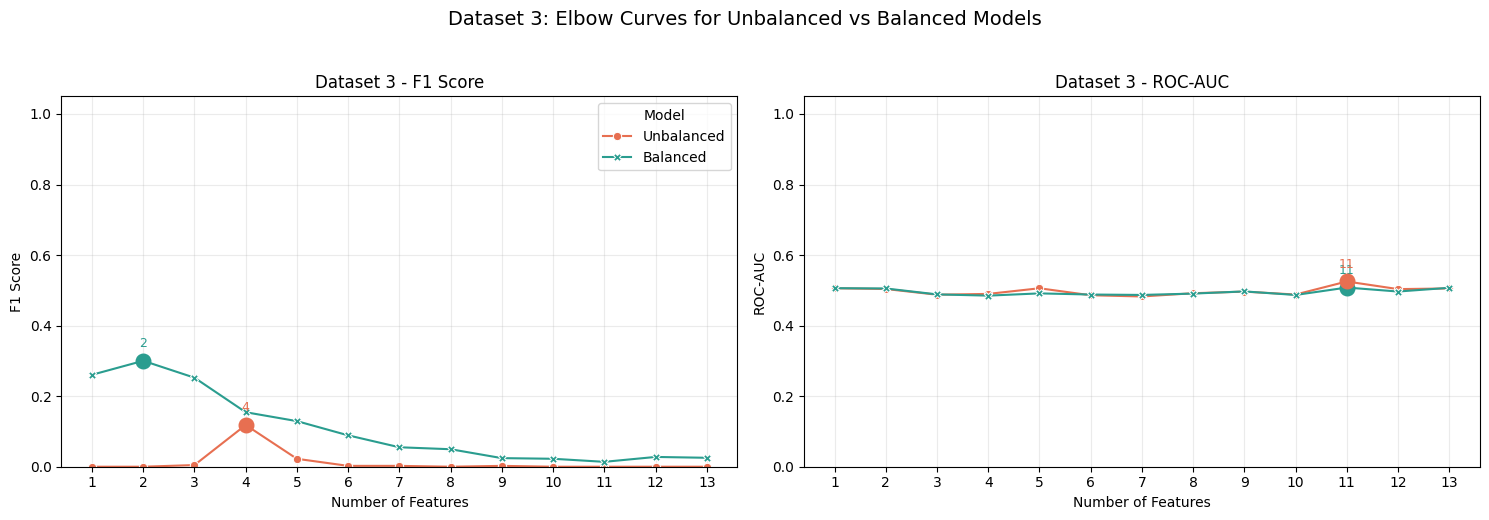

In [16]:
def plot_elbow_curves(unbalanced_df, balanced_df, dataset_name):
    plot_df = pd.DataFrame({
        "n_features": unbalanced_df["n_features"],
        "unbalanced_f1": unbalanced_df["f1"],
        "balanced_f1": balanced_df["f1"],
        "unbalanced_roc_auc": unbalanced_df["roc_auc"],
        "balanced_roc_auc": balanced_df["roc_auc"],
    })

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
    metrics = ["f1", "roc_auc"]
    metric_titles = {"f1": "F1 Score", "roc_auc": "ROC-AUC"}
    palette = {"Unbalanced": "#E76F51", "Balanced": "#2A9D8F"}

    for ax, metric in zip(axes, metrics):
        metric_df = plot_df[["n_features", f"unbalanced_{metric}", f"balanced_{metric}"]].melt(
            id_vars="n_features",
            var_name="model",
            value_name="score",
        )
        metric_df["model"] = metric_df["model"].map({
            f"unbalanced_{metric}": "Unbalanced",
            f"balanced_{metric}": "Balanced",
        })

        sns.lineplot(
            data=metric_df,
            x="n_features",
            y="score",
            hue="model",
            style="model",
            markers=True,
            dashes=False,
            palette=palette,
            ax=ax,
        )

        best_points = metric_df.loc[metric_df.groupby("model")["score"].idxmax()]
        for _, row in best_points.iterrows():
            ax.scatter(row["n_features"], row["score"], s=110, color=palette[row["model"]], zorder=5)
            ax.annotate(
                f"{int(row['n_features'])}",
                (row["n_features"], row["score"]),
                textcoords="offset points",
                xytext=(0, 10),
                ha="center",
                fontsize=9,
                color=palette[row["model"]],
            )

        ax.set_title(f"{dataset_name} - {metric_titles[metric]}")
        ax.set_xlabel("Number of Features")
        ax.set_ylabel(metric_titles[metric])
        ax.set_xticks(range(1, len(plot_df) + 1))
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.25)

    axes[0].legend(title="Model")
    axes[1].legend_.remove()
    fig.suptitle(f"{dataset_name}: Elbow Curves for Unbalanced vs Balanced Models", y=1.03, fontsize=14)
    plt.tight_layout()
    plt.show()


plot_elbow_curves(results_df_unbalanced, results_df, "Dataset 1")
plot_elbow_curves(results_df2_unbalanced, results_df2, "Dataset 2")
plot_elbow_curves(results_df3_unbalanced, results_df3, "Dataset 3")

The reduced-feature results reinforce that features such as **Hemoglobin Level (gms)**, **Serum Creatinine (mg/dl)**, and **Specific Gravity of urine** contribute most strongly to CKD prediction in Datasets 1 and 2, as strong performance is achieved with only a small subset of features.